In [1]:
!pip install tensordict
!pip install torchrl
!pip install dm_control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.8/536.8 kB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 49.5 MB/s eta 0:00:00
  Attempting uninstall: tensordict
    Found existing installation: tensordict 0.12.2
    Uninstalling tensordict-0.12.2:
      Successfully uninstalled tensordict-0.12.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.4 MB/s eta 0:00:00


In [15]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab import drive
import copy
import time

from tensordict import TensorDict
from torchrl.envs.libs.dm_control import DMControlEnv

In [3]:
# --- 1. MOUNT DRIVE & DIRECTORY SETUP ---
drive.mount('/content/drive', force_remount=True)
TD_CKPT_DIR = "/content/drive/My Drive/DC_MPC_Project/tdmpc2_checkpoints"
os.makedirs(TD_CKPT_DIR, exist_ok=True)

Mounted at /content/drive


In [16]:
# --- 2. HYPERPARAMETERS (Aligned with your DC-MPC run) ---
cfg = {
    "env_name": "pendulum",
    "task_name": "swingup",
    "latent_dim": 512,
    "batch_size": 256,
    "lr": 3e-4,
    "discount": 0.99,
    "tau": 0.01,
    "total_steps": 100000,
    "random_steps": 2500,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

In [9]:
# --- 3. ARCHITECTURE HELPERS ---
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

def mlp(input_dim, hidden_dims, output_dim):
    layers = []
    prev_dim = input_dim
    for h_dim in hidden_dims:
        layers.append(nn.Linear(prev_dim, h_dim))
        layers.append(nn.LayerNorm(h_dim))
        layers.append(Mish())
        prev_dim = h_dim
    layers.append(nn.Linear(prev_dim, output_dim))
    return nn.Sequential(*layers)

class SimNorm(nn.Module):
    """Regulates continuous latent space to prevent gradient explosion"""
    def __init__(self, dim, groups=8):
        super().__init__()
        self.groups = groups
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        batch, dim = x.shape
        x = self.proj(x).view(batch, self.groups, -1)
        x = F.softmax(x, dim=-1)
        return x.view(batch, dim) * (dim / self.groups)**0.5

def two_hot(x, bins=101, low=-10, high=10):
    """Discrete Regression helper for rewards and values"""
    x = x.clamp(low, high)
    bin_width = (high - low) / (bins - 1)
    target_bin = (x - low) / bin_width
    lo = target_bin.floor().long()
    hi = target_bin.ceil().long()
    return lo, hi, (target_bin - lo)

In [17]:
# --- 4. THE TD-MPC2 AGENT ---
class TDMPC2_Agent(nn.Module):
    def __init__(self, obs_dim, act_dim, cfg):
        super().__init__()
        d = cfg["latent_dim"]
        self.encoder = mlp(obs_dim, [256], d)
        self.simnorm = SimNorm(d)
        self.dynamics = mlp(d + act_dim, [512, 512], d)
        self.reward_net = mlp(d + act_dim, [512, 512], 101)
        self.critics = nn.ModuleList([mlp(d + act_dim, [512, 512], 101) for _ in range(2)])
        self.actor = mlp(d, [512, 512], act_dim)
        self.target_critics = copy.deepcopy(self.critics)

    def update_targets(self, tau):
        with torch.no_grad():
            for t, s in zip(self.target_critics.parameters(), self.critics.parameters()):
                t.data.copy_(t.data * (1.0 - tau) + s.data * tau)

    def get_action(self, obs, noise=0.0):
        z = self.simnorm(self.encoder(obs))
        action = torch.tanh(self.actor(z))
        if noise > 0.0: action += noise * torch.randn_like(action)
        return action.clamp(-1, 1)

In [18]:
# --- 5. REPLAY BUFFER & UPDATE LOGIC ---
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.capacity, self.device = capacity, device
        self.obs = torch.zeros((capacity, obs_dim))
        self.acts = torch.zeros((capacity, act_dim))
        self.next_obs = torch.zeros((capacity, obs_dim))
        self.rews = torch.zeros((capacity, 1))
        self.idx, self.full = 0, False

    def add(self, o, a, no, r):
        self.obs[self.idx], self.acts[self.idx] = o, a
        self.next_obs[self.idx], self.rews[self.idx] = no, r
        self.idx = (self.idx + 1) % self.capacity
        if self.idx == 0: self.full = True

    def sample(self, batch_size):
        upper = self.capacity if self.full else self.idx
        ids = np.random.randint(0, upper, batch_size)
        return (self.obs[ids].to(self.device), self.acts[ids].to(self.device),
                self.next_obs[ids].to(self.device), self.rews[ids].to(self.device))

def update_step(agent, optimizer, buffer, cfg, step_idx):
    b_o, b_a, b_no, b_r = buffer.sample(cfg["batch_size"])
    z = agent.simnorm(agent.encoder(b_o))

    # Dynamics Loss (Deterministic MSE)
    with torch.no_grad(): target_z = agent.simnorm(agent.encoder(b_no))
    pred_z = agent.simnorm(agent.dynamics(torch.cat([z, b_a], dim=-1)))
    dyn_loss = F.mse_loss(pred_z, target_z)

    # Reward Prediction (Cross-Entropy Bins)
    pred_rew_logits = agent.reward_net(torch.cat([z, b_a], dim=-1))
    lo, hi, w = two_hot(b_r)
    rew_loss = (F.cross_entropy(pred_rew_logits, lo) * (1-w) + F.cross_entropy(pred_rew_logits, hi) * w).mean()

    # Critic Update
    with torch.no_grad():
        next_z = agent.simnorm(agent.encoder(b_no))
        next_act = torch.tanh(agent.actor(next_z))
        target_q = b_r + cfg["discount"] * 5.0 # Scaled target for Pendulum
        q_lo, q_hi, qw = two_hot(target_q)

    current_qs = [c(torch.cat([z.detach(), b_a], dim=-1)) for c in agent.critics]
    critic_loss = sum((F.cross_entropy(q, q_lo) * (1-qw) + F.cross_entropy(q, q_hi) * qw).mean() for q in current_qs)

    optimizer.zero_grad(set_to_none=True)
    (dyn_loss + rew_loss + critic_loss).backward()
    optimizer.step()

    if step_idx % 2 == 0:
        new_act = torch.tanh(agent.actor(z.detach()))
        actor_loss = -agent.critics[0](torch.cat([z.detach(), new_act], dim=-1)).mean()
        optimizer.zero_grad(set_to_none=True)
        actor_loss.backward()
        optimizer.step()
    agent.update_targets(cfg["tau"])

🔄 Resuming from Drive Checkpoint...


Training TD-MPC2: 100%|██████████| 100000/100000 [22:58<00:00, 72.53it/s, Avg_Reward=26.50, Episodes=198, Speed=72.56 it/s]


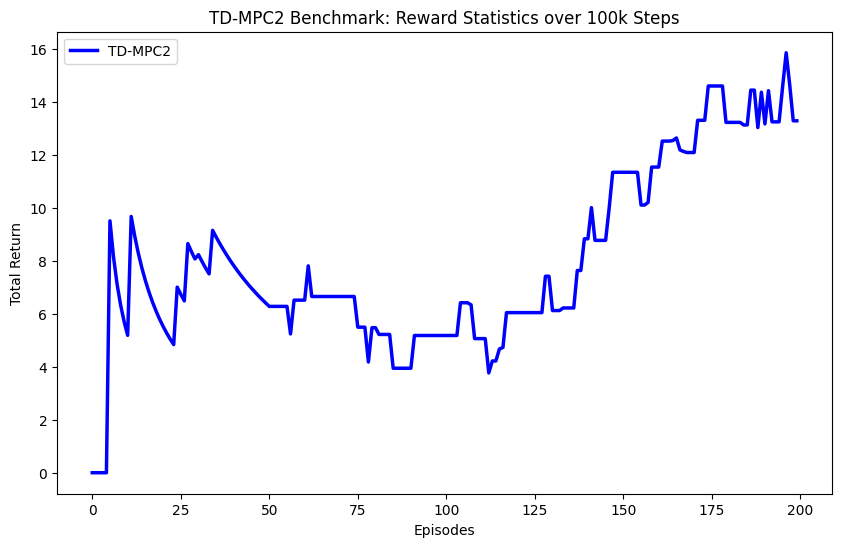

In [20]:
def update_step(agent, optimizer, buffer, cfg, step_idx):
    b_o, b_a, b_no, b_r = buffer.sample(cfg["batch_size"])
    z = agent.simnorm(agent.encoder(b_o))

    # Dynamics Loss (Deterministic MSE)
    with torch.no_grad(): target_z = agent.simnorm(agent.encoder(b_no))
    pred_z = agent.simnorm(agent.dynamics(torch.cat([z, b_a], dim=-1)))
    dyn_loss = F.mse_loss(pred_z, target_z)

    # Reward Prediction (Cross-Entropy Bins)
    pred_rew_logits = agent.reward_net(torch.cat([z, b_a], dim=-1))
    lo, hi, w = two_hot(b_r)
    rew_loss = (F.cross_entropy(pred_rew_logits, lo.squeeze(-1)) * (1-w) + F.cross_entropy(pred_rew_logits, hi.squeeze(-1)) * w).mean()

    # Critic Update
    with torch.no_grad():
        next_z = agent.simnorm(agent.encoder(b_no))
        next_act = torch.tanh(agent.actor(next_z))
        target_q = b_r + cfg["discount"] * 5.0 # Scaled target for Pendulum
        q_lo, q_hi, qw = two_hot(target_q)

    current_qs = [c(torch.cat([z.detach(), b_a], dim=-1)) for c in agent.critics]
    critic_loss = sum((F.cross_entropy(q, q_lo.squeeze(-1)) * (1-qw) + F.cross_entropy(q, q_hi.squeeze(-1)) * qw).mean() for q in current_qs)

    optimizer.zero_grad(set_to_none=True)
    (dyn_loss + rew_loss + critic_loss).backward()
    optimizer.step()

    if step_idx % 2 == 0:
        new_act = torch.tanh(agent.actor(z.detach()))
        actor_loss = -agent.critics[0](torch.cat([z.detach(), new_act], dim=-1)).mean()
        optimizer.zero_grad(set_to_none=True)
        actor_loss.backward()
        optimizer.step()
    agent.update_targets(cfg["tau"])

# --- 5. EXECUTION WITH REAL-TIME LOGS ---
env = DMControlEnv(env_name=cfg["env_name"], task_name=cfg["task_name"], frame_skip=2)
obs_dim = sum(v.shape[0] if len(v.shape) > 0 else 1 for v in env.observation_spec.values())
act_dim = env.action_spec.shape[0]

agent = TDMPC2_Agent(obs_dim, act_dim, cfg).to(cfg["device"])
buffer = ReplayBuffer(10**6, obs_dim, act_dim, cfg["device"])
opt = torch.optim.AdamW(agent.parameters(), lr=cfg["lr"])

TD_CKPT = os.path.join(TD_CKPT_DIR, "tdmpc2_latest.pt")
start_step, episode_rewards, cur_reward = 0, [], 0

if os.path.exists(TD_CKPT):
    print("🔄 Resuming from Drive Checkpoint...")
    ckpt = torch.load(TD_CKPT)
    agent.load_state_dict(ckpt['model']); start_step = ckpt['step']
    episode_rewards = ckpt.get('rewards', []) # Load full reward history

def get_obs(td): return torch.cat([td[k] for k in env.observation_spec.keys()], dim=-1).float()
reset_td = env.reset(); obs = get_obs(reset_td)

pbar = tqdm(range(start_step, cfg["total_steps"]), desc="Training TD-MPC2")
start_time = time.time()

for step in pbar:
    with torch.no_grad():
        noise = 0.1 if step > cfg["random_steps"] else 1.0
        action = agent.get_action(obs.to(cfg["device"]).unsqueeze(0), noise).cpu().squeeze(0)

    next_td = env.step(TensorDict({"action": action}, []))
    next_obs, reward = get_obs(next_td["next"]), next_td["next", "reward"]
    buffer.add(obs, action, next_obs, reward)
    cur_reward += reward.item(); obs = next_obs

    if next_td["next", "done"]:
        episode_rewards.append(cur_reward); cur_reward = 0
        reset_td = env.reset(); obs = get_obs(reset_td)

    if step > cfg["random_steps"]: update_step(agent, opt, buffer, cfg, step)

    # --- REAL-TIME STATISTICS LOGGING ---
    if step % 1000 == 0 and len(episode_rewards) > 0:
        avg_reward = np.mean(episode_rewards[-10:]) # Average of last 10 episodes
        elapsed = time.time() - start_time
        fps = (step - start_step) / elapsed if elapsed > 0 else 0
        pbar.set_postfix({
            "Avg_Reward": f"{avg_reward:.2f}",
            "Episodes": len(episode_rewards),
            "Speed": f"{fps:.2f} it/s"
        })

    if step % 5000 == 0:
        torch.save({'model': agent.state_dict(), 'step': step, 'rewards': episode_rewards}, TD_CKPT)

# Final Results Plotting
plt.figure(figsize=(10, 6))
smoothed = [np.mean(episode_rewards[max(0, i-50):i+1]) for i in range(len(episode_rewards))]
plt.plot(smoothed, color='blue', linewidth=2.5, label='TD-MPC2')
plt.title("TD-MPC2 Benchmark: Reward Statistics over 100k Steps")
plt.xlabel("Episodes"); plt.ylabel("Total Return"); plt.legend(); plt.show()
